In [ ]:
import os, gc, re, glob, shutil, random, warnings
import cv2, yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch
import torch.nn as nn
import torchvision.transforms as T
import torchvision.models as models
from sklearn.model_selection import train_test_split
from ultralytics import YOLO
warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
OUT    = '/kaggle/working/outputs'
os.makedirs(OUT, exist_ok=True)

BASE_IN = '/kaggle/input/datasets/anasaboassaf'

# Define paths based on actual structure
YOLO_OUT    = f'{YOLO_IN}/outputs'
TRAIN_V2    = f'{YOLO_IN}/yolo11_fire_smoke/train_v2'



# Set file paths
best_yolo_path = os.path.join(YOLO_OUT, 'best_yolo.pt')
results_csv_path = os.path.join(TRAIN_V2, 'results.csv')

alt_flame2_path = os.path.join(YOLO_OUT, 'flame2_clf.pt')



✅ Loaded 100 epochs from results.csv

Best epoch metrics:
  Best epoch : 99
  mAP50      : 0.9846
  mAP50-95   : 0.7738
  Precision  : 0.9620
  Recall     : 0.9540


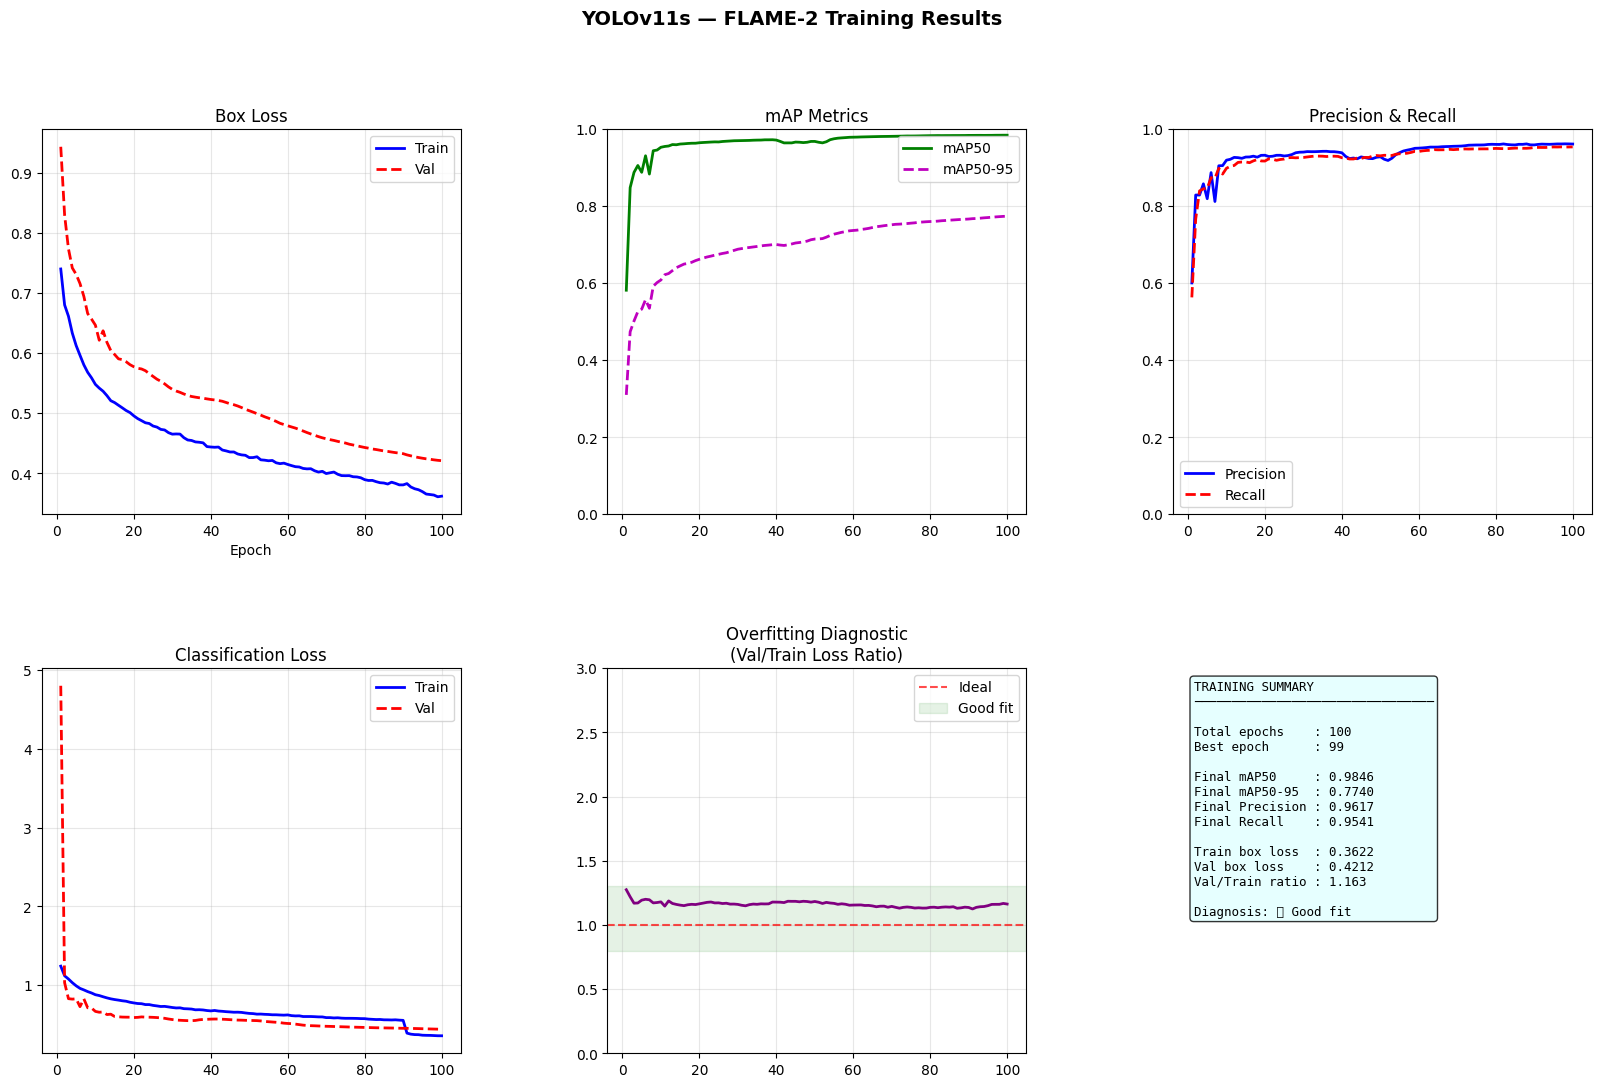

💾 Saved → /kaggle/working/outputs/training_curves.png


In [3]:
df = pd.read_csv(f'{TRAIN_V2}/results.csv')
df.columns = df.columns.str.strip()
df = df[np.isfinite(df['train/box_loss'])].copy()
ep = df['epoch']
 
print(f"✅ Loaded {len(df)} epochs from results.csv")
print(f"\nBest epoch metrics:")
best_idx = df['metrics/mAP50(B)'].idxmax()
best     = df.loc[best_idx]
print(f"  Best epoch : {int(best['epoch'])}")
print(f"  mAP50      : {best['metrics/mAP50(B)']:.4f}")
print(f"  mAP50-95   : {best['metrics/mAP50-95(B)']:.4f}")
print(f"  Precision  : {best['metrics/precision(B)']:.4f}")
print(f"  Recall     : {best['metrics/recall(B)']:.4f}")
 
fig = plt.figure(figsize=(20, 12))
fig.suptitle('YOLOv11s — FLAME-2 Training Results\n',
             fontsize=14, fontweight='bold')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)
 
# 1. Box loss
ax1 = fig.add_subplot(gs[0,0])
ax1.plot(ep, df['train/box_loss'], 'b-',  lw=2, label='Train')
ax1.plot(ep, df['val/box_loss'],   'r--', lw=2, label='Val')
ax1.set_title('Box Loss'); ax1.set_xlabel('Epoch')
ax1.legend(); ax1.grid(True, alpha=0.3)
 
# 2. mAP
ax2 = fig.add_subplot(gs[0,1])
ax2.plot(ep, df['metrics/mAP50(B)'],    'g-',  lw=2, label='mAP50')
ax2.plot(ep, df['metrics/mAP50-95(B)'], 'm--', lw=2, label='mAP50-95')
ax2.set_title('mAP Metrics'); ax2.set_ylim(0,1)
ax2.legend(); ax2.grid(True, alpha=0.3)
 
# 3. Precision & Recall
ax3 = fig.add_subplot(gs[0,2])
ax3.plot(ep, df['metrics/precision(B)'].clip(0,1), 'b-',  lw=2, label='Precision')
ax3.plot(ep, df['metrics/recall(B)'].clip(0,1),    'r--', lw=2, label='Recall')
ax3.set_title('Precision & Recall'); ax3.set_ylim(0,1)
ax3.legend(); ax3.grid(True, alpha=0.3)
 
# 4. Cls loss
ax4 = fig.add_subplot(gs[1,0])
ax4.plot(ep, df['train/cls_loss'], 'b-',  lw=2, label='Train')
ax4.plot(ep, df['val/cls_loss'],   'r--', lw=2, label='Val')
ax4.set_title('Classification Loss')
ax4.legend(); ax4.grid(True, alpha=0.3)
 
# 5. Val/Train ratio
ax5 = fig.add_subplot(gs[1,1])
ratio = (df['val/box_loss'] / df['train/box_loss']).clip(0, 3)
ax5.plot(ep, ratio, 'purple', lw=2)
ax5.axhline(1.0, color='red',   linestyle='--', alpha=0.7, label='Ideal')
ax5.axhspan(0.8, 1.3, alpha=0.1, color='green', label='Good fit')
ax5.set_title('Overfitting Diagnostic\n(Val/Train Loss Ratio)')
ax5.set_ylim(0, 3); ax5.legend(); ax5.grid(True, alpha=0.3)
 
# 6. Summary
ax6 = fig.add_subplot(gs[1,2])
ax6.axis('off')
last       = df.iloc[-1]
final_ratio = ratio.iloc[-1]
diag = ('✅ Good fit'      if 0.8 <= final_ratio <= 1.3
        else '⚠️ Overfitting' if final_ratio > 1.3
        else '⚠️ Underfitting')
summary = (
    f"TRAINING SUMMARY\n{'─'*32}\n\n"
    f"Total epochs    : {len(df)}\n"
    f"Best epoch      : {int(best['epoch'])}\n\n"
    f"Final mAP50     : {last['metrics/mAP50(B)']:.4f}\n"
    f"Final mAP50-95  : {last['metrics/mAP50-95(B)']:.4f}\n"
    f"Final Precision : {last['metrics/precision(B)']:.4f}\n"
    f"Final Recall    : {last['metrics/recall(B)']:.4f}\n\n"
    f"Train box loss  : {last['train/box_loss']:.4f}\n"
    f"Val box loss    : {last['val/box_loss']:.4f}\n"
    f"Val/Train ratio : {final_ratio:.3f}\n\n"
    f"Diagnosis: {diag}"
)
ax6.text(0.05, 0.97, summary, transform=ax6.transAxes,
         fontsize=9, va='top', family='monospace',
         bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.8))
 
plt.savefig(f'{OUT}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"💾 Saved → {OUT}/training_curves.png")
